In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.special import hankel2
from IPython.display import HTML
import ipympl


In [2]:
# Wave speed
# Fundamentele constanten
eps0 = 8.854187817e-12   # F/m
mu0  = 4*np.pi*1e-7      # H/m
c   = 1/np.sqrt(eps0*mu0)

# Domain parameters
domain_width = 2*10**8
domain_height = 2*10**8

# Frequency range
sigma = 0.2*10**-1
f_max = (5/sigma)/(2*np.pi)
omega_max=2*np.pi*f_max
# Grid
lambda_min = c / f_max       # minimum wavelength
dx = lambda_min / 20        # spatial step
dy = dx
CFL = 0.999999
dt = CFL / (c*np.sqrt(1/dx**2 + 1/dy**2))     # CFL condition

Nx, Ny = round(domain_width / dx), round(domain_height / dy)

Nt = round((15 * sigma / dt))    # max time steps

# Source
ps_x_co=domain_width/2
ps_y_co=domain_height/2
ps_x = int(ps_x_co/dx)
ps_y = int(ps_y_co/dy)

J0 = 10
tc = 5*sigma
def ps(t):
    return J0*np.exp(-(t-tc)**2/(2*sigma**2))
 
# Observation points
po_x_co=domain_width/2
po_y_co=domain_height/1.8
po_x = int(po_x_co/dx)
po_y = int(po_y_co/dy)


print(f"Grid size: {Nx} x {Ny}, Time steps: {Nt},c={c}")
print(f"dx = {dx:.4f} m, dt = {dt:.6f} s")
print(f"Lambda_min = {lambda_min:.4f} m, points per wavelength = {lambda_min/dx:.1f}")

Grid size: 531 x 531, Time steps: 338,c=299792458.0105029
dx = 376730.3135 m, dt = 0.000889 s
Lambda_min = 7534606.2695 m, points per wavelength = 20.0


In [3]:
# Definition of kappa
d_PML = domain_width/4
N_PML= int(d_PML/dx)               # gewenste reflectie
m  = 3.5
eta0=np.sqrt(mu0/eps0)

print(N_PML)
sigma_max   = (m + 1) / (2 * eta0 * d_PML)*11
sigma_m_max =  sigma_max * mu0 / eps0

sigma_pml   = sigma_max   * (np.arange(N_PML + 1) / N_PML) ** m
sigma_m_pml = sigma_m_max * (np.arange(N_PML + 1) / N_PML) ** m


def sigma_PML(E_or_H):
    kappa_m = np.zeros(((Nx+1)-1*(E_or_H=='Hy'), (Ny+1)-1*(E_or_H=='Hx')))

    if E_or_H=='Ezx':
        kappa_m[:N_PML+1, :] = sigma_pml[::-1, np.newaxis]     # ::-1 to invert the kappa array to match the def of kappa; np.newaxis to match dimensions
        kappa_m[-N_PML-1:, :] = sigma_pml[:, np.newaxis]
        
    if E_or_H=='Ezy':
        kappa_m[:,-N_PML-1:] = sigma_pml[np.newaxis, :]
        kappa_m[:, :N_PML+1] = sigma_pml[np.newaxis, ::-1]
    
    if E_or_H=='Hx':
        kappa_m[:N_PML+1, :] = sigma_m_pml[::-1, np.newaxis]     # ::-1 to invert the kappa array to match the def of kappa; np.newaxis to match dimensions
        kappa_m[-N_PML-1:, :] = sigma_m_pml[:, np.newaxis]
        
    if E_or_H=='Hy':
        kappa_m[:,-N_PML-1:] = sigma_m_pml[np.newaxis, :]
        kappa_m[:, :N_PML+1] = sigma_m_pml[np.newaxis, ::-1]
    
    return kappa_m


132


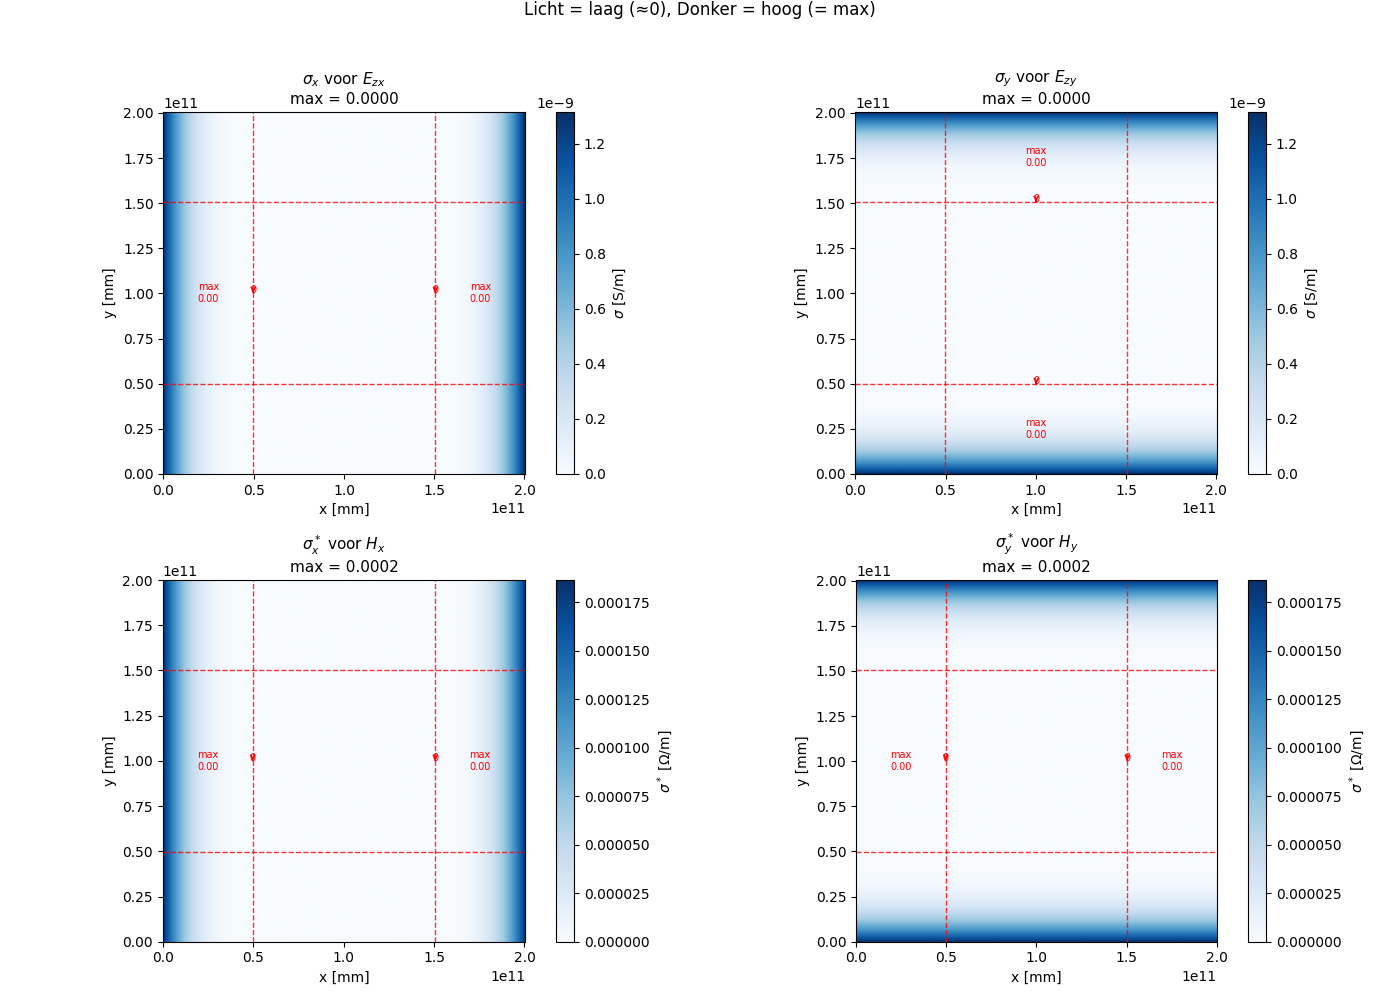

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

components = ['Ezx', 'Ezy', 'Hx', 'Hy']
titles = ['$\\sigma_x$ voor $E_{zx}$', '$\\sigma_y$ voor $E_{zy}$',
          '$\\sigma^*_x$ voor $H_x$', '$\\sigma^*_y$ voor $H_y$']

for ax, comp, title in zip(axes.flatten(), components, titles):
    data = sigma_PML(comp)
    
    vmax = data.max()
    im = ax.imshow(data.T, origin='lower', cmap='Blues',
                   vmin=0, vmax=vmax,
                   extent=[0, data.shape[0]*dx*1e3, 0, data.shape[1]*dy*1e3])
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('$\\sigma$ [S/m]' if 'E' in comp else '$\\sigma^*$ [Ω/m]')
    cbar.ax.axhline(y=vmax, color='red', lw=1.5, label=f'max={vmax:.3f}')
    
    # PML-grenzen aanduiden
    for lim in [N_PML*dx*1e3, (data.shape[0]-N_PML)*dx*1e3]:
        ax.axvline(lim, color='red', lw=1, ls='--', alpha=0.8)
    for lim in [N_PML*dy*1e3, (data.shape[1]-N_PML)*dy*1e3]:
        ax.axhline(lim, color='red', lw=1, ls='--', alpha=0.8)

    # Annoteer de gradiëntrichting in elke PML-zone
    cx = data.shape[0] * dx * 1e3 / 2   # midden van het domein
    cy = data.shape[1] * dy * 1e3 / 2

    arrow_kw = dict(fontsize=7, color='red', ha='center',
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

    if 'x' in comp.lower() or comp == 'Hy':
        # gradiënt in x-richting
        ax.annotate('0', xy=(N_PML*dx*1e3, cy),
                    xytext=(N_PML*dx*1e3 + 1.5, cy), **arrow_kw)
        ax.annotate('0', xy=((data.shape[0]-N_PML)*dx*1e3, cy),
                    xytext=((data.shape[0]-N_PML)*dx*1e3 - 1.5, cy), **arrow_kw)
        ax.text(0.5*N_PML*dx*1e3, cy, f'max\n{vmax:.2f}',
                color='red', fontsize=7, ha='center', va='center')
        ax.text((data.shape[0]-0.5*N_PML)*dx*1e3, cy, f'max\n{vmax:.2f}',
                color='red', fontsize=7, ha='center', va='center')
    else:
        # gradiënt in y-richting
        ax.annotate('0', xy=(cx, N_PML*dy*1e3),
                    xytext=(cx, N_PML*dy*1e3 + 1.5), **arrow_kw)
        ax.annotate('0', xy=(cx, (data.shape[1]-N_PML)*dy*1e3),
                    xytext=(cx, (data.shape[1]-N_PML)*dy*1e3 - 1.5), **arrow_kw)
        ax.text(cx, 0.5*N_PML*dy*1e3, f'max\n{vmax:.2f}',
                color='red', fontsize=7, ha='center', va='center')
        ax.text(cx, (data.shape[1]-0.5*N_PML)*dy*1e3, f'max\n{vmax:.2f}',
                color='red', fontsize=7, ha='center', va='center')

    ax.set_title(f'{title}\nmax = {vmax:.4f}', fontsize=11)
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')

plt.suptitle('PML conductiviteitsprofielen — rood gestippeld: PML-grens\n'
             'Licht = laag (≈0), Donker = hoog (= max)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [5]:
    #uniform    
    # Materiaalmatrices (relatieve permittiviteit, permeabiliteit, geleiding)
    eps_r = np.ones((Nx+1, Ny+1))
    mu_r_Hx  = np.ones((Nx+1, Ny))
    mu_r_Hy  = np.ones((Nx, Ny+1))
    sigma_e = np.zeros((Nx+1, Ny+1))  # elektrische geleiding [S/m]

    # ── Voeg een rechthoekig diëlektrisch object toe ───────────────
    # Pas aan voor andere geometrieën
    USE_OBJECT = False

    # dielectric
    diel_x = domain_width/1.8 #(middle of the object)
    diel_y = domain_height/2 #(middle of the object)
    diel_height = domain_height/3.5
    diel_width = domain_width/5 

    if USE_OBJECT:
        obj_x0, obj_x1 = int((diel_x-diel_width/2)/dx),  int((diel_x+diel_width/2)/dx)   # x-bereik (indices)
        obj_y0, obj_y1 = int((diel_y-diel_height/2)/dy), int((diel_y+diel_height/2)/dy)   # y-bereik (indices)
        eps_r[obj_x0:obj_x1, obj_y0:obj_y1]   = 1   # relatieve permittiviteit
        sigma_e[obj_x0:obj_x1, obj_y0:obj_y1] = 0.005   # geleiding (0 = verliesvrij)

    print('Materiaalmatrices aangemaakt.')
    if USE_OBJECT:
        print(f'Object: eps_r={eps_r[obj_x0+1, obj_y0+1]:.1f}, '
            f'afmeting {(obj_x1-obj_x0)*dx*1e3:.0f}x{(obj_y1-obj_y0)*dy*1e3:.0f} mm')

Materiaalmatrices aangemaakt.


In [ ]:
#uniform

# ── Coëfficiënten voor H_x  (afhankelijk van sigma_y*, mu_r) ──
# sigma_x* is gedefinieerd op de y-as → maak 2D door broadcasting
smx  = sigma_PML('Hx')

denom_hx = 1 + smx*dt/(2*mu0*mu_r_Hx)
Chxa = (1 - smx*dt/(2*mu0*mu_r_Hx)) / denom_hx
Chxb = (dt/(mu0*mu_r_Hx)) / denom_hx #/ dy       # inclusief 1/dy

# ── Coëfficiënten voor H_y  (afhankelijk van sigma_y*, mu_r) ──
smy  = sigma_PML('Hy') # shape (Nx, Ny)

denom_hy = 1 + smy*dt/(2*mu0*mu_r_Hy)
Chya = (1 - smy*dt/(2*mu0*mu_r_Hy)) / denom_hy
Chyb = (dt/(mu0*mu_r_Hy)) / denom_hy #/ dx       # inclusief 1/dx

# ── Coëfficiënten voor E_zx  (afhankelijk van sigma_x, eps_r) ─
sx   = sigma_PML('Ezx') # shape (Nx, Ny)
sigma_x = sx + sigma_e/2
epsr = eps_r                                   # shape (Nx, Ny)

denom_ezx = 1 + sigma_x*dt/(2*eps0*epsr)
Cexa = (1 - sigma_x*dt/(2*eps0*epsr)) / denom_ezx
Cexb = (dt/(eps0*epsr)) / denom_ezx #/ dx     # inclusief 1/dx

# ── Coëfficiënten voor E_zy  (afhankelijk van sigma_y, eps_r) ─
sy   = sigma_PML('Ezy') # shape (Nx, Ny)
sigma_y = sy + sigma_e/2

denom_ezy = 1 + sigma_y*dt/(2*eps0*epsr)
Ceya = (1 - sigma_y*dt/(2*eps0*epsr)) / denom_ezy
Ceyb = (dt/(eps0*epsr)) / denom_ezy #/ dy     # inclusief 1/dy

print('Update-coëfficiënten berekend.')
print(f'Shapes: Chxa={Chxa.shape}, Chya={Chya.shape}')
print(f'Shapes: Cexa={Cexa.shape}, Ceya={Ceya.shape}')

In [ ]:
#uniform:

# ── Veldmatrices initialiseren ─────────────────────────────────
Hx  = np.zeros((Nx+1, Ny))
Hy  = np.zeros((Nx, Ny+1))
Ezx = np.zeros((Nx+1, Ny+1))   # gesplitste E_z component (x-richting)
Ezy = np.zeros((Nx+1, Ny+1))   # gesplitste E_z component (y-richting)

# Observatie-tijdreeksen
Ez_obs    = np.zeros(Nt)
Je_t      = np.zeros(Nt)
Aantal_snap_times = 50
snap_times = np.linspace(0, Nt-1, Aantal_snap_times, dtype=int)   # tijdstappen om snapshot op te slaan
snapshots  = {}

print('Start tijdintegratie...')
print(dt,dx,dy)
for n in range(Nt):
    t_now = n * dt

    # ── Stap 1: Update H-velden ────────────────────────────────
    # H_x: i=0..Nx-1, j=0..Ny-2  (centrale diff in y-richting)
    Hx[:, :] = (Chxa[:, :] * Hx[:, :]
                  - Chxb[:, :]*(1/dy) * (Ezx[:, 1:] + Ezy[:, 1:]
                                  - Ezx[:, :-1] - Ezy[:, :-1]))

    # H_y: i=0..Nx-2, j=0..Ny-1  (centrale diff in x-richting)
    Hy[:, :] = (Chya[:, :] * Hy[:, :]
                  + Chyb[:, :]*(1/dx) * (Ezx[1:, :] + Ezy[1:, :]
                                   - Ezx[:-1, :] - Ezy[:-1, :]))

    # ── Stap 2: PEC-randvoorwaarden H ─────────────────────────
    # (Voor PEC-backed PML: tangentiële E=0 aan rand, geen extra H-rand nodig;
    #  de PML dempt de golven voor ze de PEC-rand bereiken)

    # ── Stap 3: Update E-velden (gesplitst) ────────────────────
    # E_zx: afhankelijk van dH_y/dx
    Ezx[1:-1, :] = (Cexa[1:-1, :] * Ezx[1:-1, :]
                  + Cexb[1:-1, :]*(1/dx) * (Hy[1:, :] - Hy[:-1, :]))

    # E_zy: afhankelijk van -dH_x/dy en bron
    Ezy[:, 1:-1] = (Ceya[:, 1:-1] * Ezy[:, 1:-1]
                  - Ceyb[:, 1:-1]*(1/dy) * (Hx[:, 1:] - Hx[:, :-1]))

    # ── Stap 4: Bron injecteren ────────────────────────────────
    # Gaussische puls: J_e(t) = J0 * exp(-(t-tc)^2 / (2*sigma_t^2))
    Je_t[n] = ps(t_now)
    # Bronterm: -J_e * dt/(eps0*eps_r) toegevoegd aan E_zy op bronlocatie
    Ezy[ps_x, ps_y] -= (dt / (dx*dy*eps0 * eps_r[ps_x, ps_y])) * ps(t_now)
    # (factor dy omdat Cezyb al 1/dy bevat; bronterm is J/(eps) * dt)

    # ── Stap 5: Totaal E_z ─────────────────────────────────────
    Ez = Ezx + Ezy

    # ── Stap 6: PEC-randvoorwaarden E ─────────────────────────
    # Tangentiële E_z = 0 op alle randen (PEC-backed PML)
    Ez[0, :]  = 0
    Ez[-1, :] = 0
    Ez[:, 0]  = 0
    Ez[:, -1] = 0
    # Synchroniseer Ezx/Ezy met de PEC-randvoorwaarden
    Ezx[0, :] = 0
    Ezy[0, :]  = -Ezx[0, :]
    Ezx[-1,:] = 0
    Ezy[-1, :]  = -Ezx[-1,:]
    Ezx[:, 0] = 0
    Ezy[:, 0]  = -Ezx[:, 0]
    Ezx[:,-1] = 0
    Ezy[:, -1]  = -Ezx[:, -1]

    # ── Observatie ────────────────────────────────────────────
    Ez_obs[n] = Ez[po_x, po_y]

    # Snapshots
    if n in snap_times:
        snapshots[n] = Ez.copy()
    print(n/Nt,end="\r")
print('Tijdintegratie voltooid!')

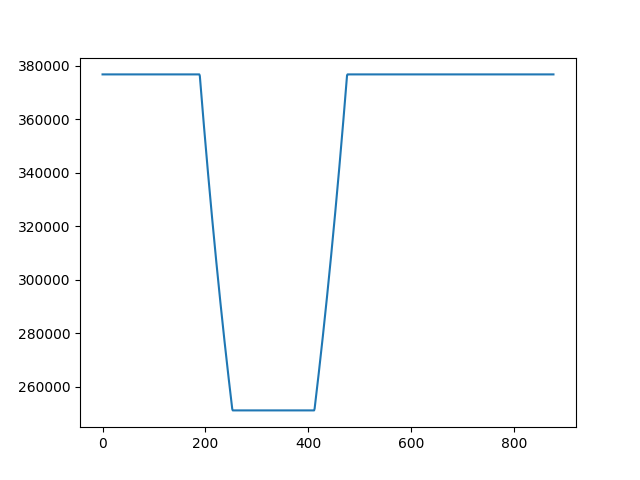

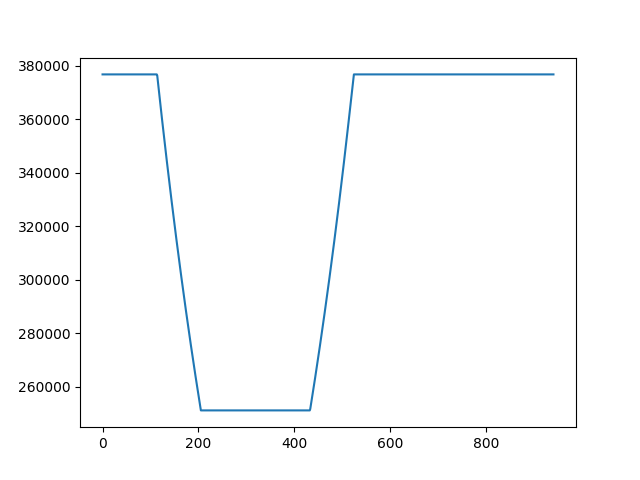

131111111.1111111 91111111.1111111


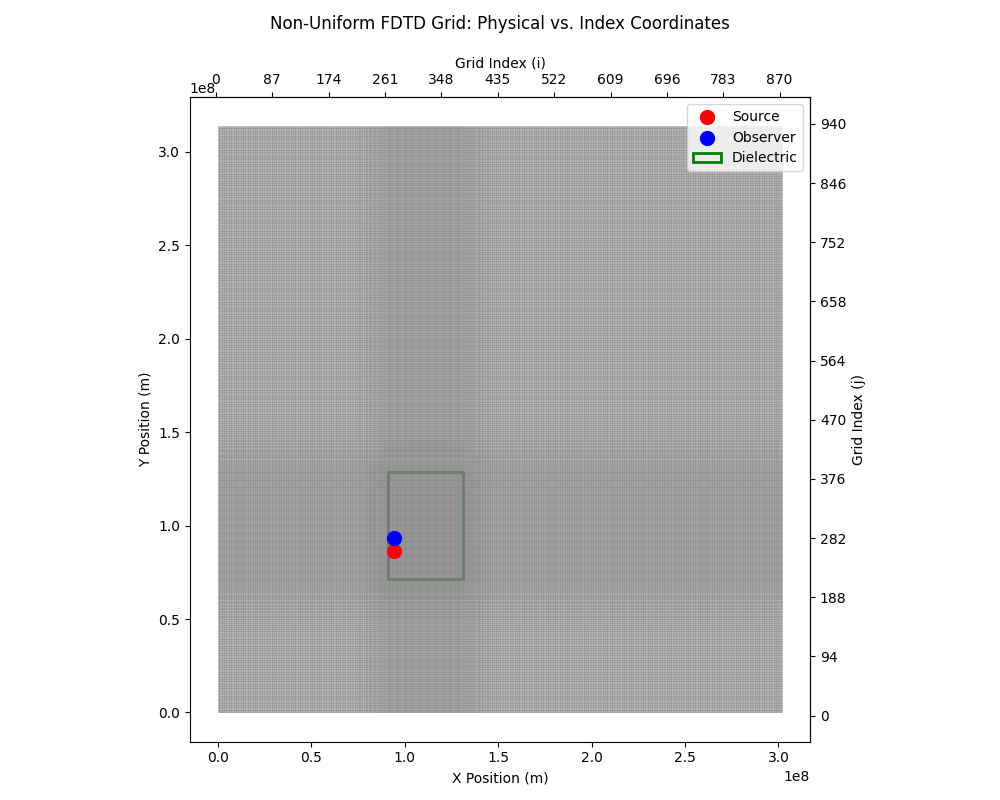

In [6]:
#refining in the object



#extra refinement functions can be ignored-------
dxr=lambda_min/30
R=dxr/dx
b=domain_width/5

r=(1-b/(2*dx))/(R-b/(2*dx))
if r>1.5 :
    print("alarm")
N=np.log(R)/np.log(r)

i=np.arange(2*N)
delta=dx*r**i*np.heaviside(-(i-N),1)+np.heaviside(i-N,1)*dxr*(1/r)**(i-N)
"""
fig,ax=plt.subplots()
ax.plot(i,delta,label="discretisation step")
ax.plot(i,np.ones_like(i)*dx,label="big step")
ax.plot(i,np.ones_like(i)*dxr,label="small step")
ax.axvline(x=N,color="red",label="midle")
ax.set_xlim([0,np.max(i)])
ax.legend()
plt.show()
"""
#refining aroud object
b=2*domain_width/5
ce=b/2
d=(b-ce)
R=dxr/dx
r=(1-d/(2*dx))/(R-d/(2*dx))
if r>1.5 :
    print("alarm")
N=np.log(R)/np.log(r)
i=np.arange(4*N)
delta=dx*r**i*np.heaviside(-(i-N),1)+np.heaviside(i-3*N,1)*dxr*(1/r)**(i-3*N)+np.heaviside(-(np.abs(i-2*N)-N),1)*dxr
"""
fig,ax=plt.subplots()
ax.plot(i,delta,label="discretisation step")
ax.plot(i,np.ones_like(i)*dx,label="big step")
ax.plot(i,np.ones_like(i)*dxr,label="small step")
ax.axvline(x=2*N,color="red",label="midle")
ax.set_xlim([0,np.max(i)])
ax.legend()
plt.show()
"""

#actual refinement ---------------------------------------------------------------------------
# dielectric around which we would like to refine
diel_x = domain_width/1.8 #(middle of the object)
diel_y = domain_height/2 #(middle of the object)
diel_height = domain_height/3.5
diel_width = domain_width/5 

# x-direction
dxr=lambda_min/30 #refined step

discr_width=diel_width       #the width over which the refinment happens => half to refine towards refined area half to unrefine outwards(see plots)
before_discrx=diel_x-diel_width/2-discr_width/2 #width before refinement starts
after_discrx=diel_x+diel_width/2+discr_width/2 # width after refinement

N_before=before_discrx/dx #amount of points before refinement(undiform)
N_after=after_discrx/dx #amount of points after refinement (uniform)
N_middle=diel_width/dxr #amount of points in refined are (uniform)

#function to figure out the refinement per step and amount of points that correspond with the wanted refinement and discrwidth
def refinement(d,dr):
    R_y=dr/dy
    r=(1-d/(2*dy))/(R_y-d/(2*dy))
    if r>1.5 or r < 2/3:
        print("alarm")
    M=np.log(R_y)/np.log(r)

    return r,M

r,N=refinement(discr_width,dxr)

N_dicr1=N #amount of steps in refinement
N_dicr2=N #amount of steps in unrefinement

N_domain=N_before+N_after+N_dicr1+N_dicr2+N_middle #total amount of steps
i=np.arange(N_domain) #indexes of points in x-direction

#function describing spatial step in x-dricetion per index (piecewise defenition)
deltax=np.heaviside(-i+N_before,1)*dx+ dx*r**(i-N_before)*np.heaviside(-(np.abs(i-(N_before+N_dicr1/2))-(N_dicr1/2)),1)+np.heaviside(-(np.abs(i-(N_before+N_dicr1+N_middle/2))-N_middle/2),1)*dxr+np.heaviside(-(np.abs(i-(N_before+N_dicr1+N_middle+N_dicr2/2))-N_dicr2/2),1)*dxr*(1/r)**(i-(N_before+N_dicr1+N_middle))+np.heaviside(i-(N_domain-N_after),1)*dx

fig,ax=plt.subplots()
ax.plot(i,deltax,label="discretisation step")

#ax.plot(i,np.ones_like(i)*dx,label="big step")
#ax.plot(i,np.ones_like(i)*dxr,label="small step")
#ax.axvline(x=N_before,color="red",label="midle")
#ax.axvline(x=N_before+N_dicr1,color="red",label="midle")
#ax.axvline(x=N_before+N_dicr1+N_middle,color="red",label="midle")
#ax.set_xlim([0,np.max(i)])
#ax.legend()
plt.show()

#function to get index of any point INCOMPLETE!!!
def get_index_x(x):
    if x<=before_discrx: #before refinement
        n=x/dx
        print("dom1")
    elif x>=(domain_width-after_discrx): # after refinement
        n=(x-(domain_width-after_discrx))/dx+(N_domain-N_after)
        print("dom2")
    elif x> (before_discrx+discr_width/2) and x< (before_discrx+discr_width/2+diel_width): # in the refined
        n=(x-(before_discrx+discr_width/2))/dxr +N_before+N_dicr1
        print("dom3")
    elif x>before_discrx and x< (before_discrx+discr_width/2): #in the first refinement
        n=1
        print("dom4")
    elif x>(before_discrx+discr_width/2+diel_width) and x<(domain_width-after_discrx) :
        n=1
        print("dom5")
    else:
        n="problem"
    return n



#y-direction
dyr=lambda_min/30


discr_height=diel_height #the heigth over which the refinment happens => half to refine towards refined area half to unrefine outwards(see plots)
before_discry=diel_y-diel_height/2-discr_height/2 #height before refinement starts
after_discry=diel_y+diel_height/2+discr_height/2 # height after refinement

M_before=before_discry/dy #amount of points before refinement(uniform)
M_after=after_discry/dy  #amount of points after refinement(uniform)
M_middle=diel_height/dyr #amount of points in the refined area (uniform)



r_y,M=refinement(discr_height,dyr)
M_dicr1=M  #amount of steps in refinement
M_dicr2=M  #amount of steps in unrefinement
 
M_domain=M_before+M_after+M_dicr1+M_dicr2+M_middle #total amount of steps domain
j=np.arange(M_domain) #indexes in y-direction

#function describing spatial step in the y direction(piecewise defenition)
deltay=np.heaviside(-j+M_before,1)*dy+ dy*r_y**(j-M_before)*np.heaviside(-(np.abs(j-(M_before+M_dicr1/2))-(M_dicr1/2)),1)+np.heaviside(-(np.abs(j-(M_before+M_dicr1+M_middle/2))-M_middle/2),1)*dyr+np.heaviside(-(np.abs(j-(M_before+M_dicr1+M_middle+M_dicr2/2))-M_dicr2/2),1)*dyr*(1/r_y)**(j-(M_before+M_dicr1+M_middle))+np.heaviside(j-(M_domain-M_after),1)*dy

fig,ax=plt.subplots()
ax.plot(j,deltay,label="discretisation step")
#ax.plot(i,np.ones_like(i)*dx,label="big step")
#ax.plot(i,np.ones_like(i)*dxr,label="small step")
#ax.axvline(x=N_before,color="red",label="midle")
#ax.axvline(x=N_before+N_dicr1,color="red",label="midle")
#ax.axvline(x=N_before+N_dicr1+N_middle,color="red",label="midle")
#ax.set_xlim([0,np.max(i)])
#ax.legend()
plt.show()


#function to get index of any point INCOMPLETE!!!
def get_index_y(y):
    if y<=before_discry: #before refinement
        n=y/dy
        print("dom1")
    elif y>=(domain_height-after_discry): # after refinement
        n=(y-(domain_height-after_discry))/dy+(M_domain-M_after)
        print("dom2")
    elif y> (before_discry+discr_height/2) and y< (before_discry+discr_height/2+diel_height): # in the refined
        n=(y-(before_discry+discr_height/2))/dyr +M_before+M_dicr1
        print("dom3")
    elif y>before_discry and y< (before_discry+discr_height/2): #in the first refinement
        n=1
        print("dom4")
    elif y>(before_discry+discr_height/2+diel_height) and y<(domain_height-after_discry) :
        n=1
        print("dom5")
    else:
        n="problem"
    return n



#visualising grid

import matplotlib.pyplot as plt
import numpy as np

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.interpolate import interp1d

# 1. Reconstruct physical coordinates
x_edges = np.concatenate(([0], np.cumsum(deltax)))
y_edges = np.concatenate(([0], np.cumsum(deltay)))
indices_x = np.arange(len(x_edges))
indices_y = np.arange(len(y_edges))

# Create mapping functions for the secondary axes
# Since it's non-uniform, we interpolate between the physical edge and the index
f_x = interp1d(x_edges, indices_x, fill_value="extrapolate")
f_y = interp1d(y_edges, indices_y, fill_value="extrapolate")

fig, ax = plt.subplots(figsize=(10, 8))

# 2. Draw the vertical and horizontal grid lines
ax.vlines(x_edges, ymin=y_edges[0], ymax=y_edges[-1], color='gray', lw=0.5, alpha=0.5)
ax.hlines(y_edges, xmin=x_edges[0], xmax=x_edges[-1], color='gray', lw=0.5, alpha=0.5)

# 3. Highlight specific points
x_src, y_src = x_edges[ps_x], y_edges[ps_y]
x_obs, y_obs = x_edges[po_x], y_edges[po_y]

ax.scatter(x_src, y_src, color='red', s=100, label='Source', zorder=5)
ax.scatter(x_obs, y_obs, color='blue', s=100, label='Observer', zorder=5)

# 4. Visualize Dielectric Object
rect = Rectangle((diel_x - diel_width/2, diel_y - diel_height/2), 
                 diel_width, diel_height, 
                 linewidth=2, edgecolor='green', facecolor='none', label='Dielectric')
ax.add_patch(rect)
print(diel_x+diel_width/2,diel_x-diel_width/2)
# --- Secondary Axes Logic ---
# Secondary X-axis for Grid Index
secax_x = ax.secondary_xaxis('top', functions=(f_x, lambda x: x))
secax_x.set_xlabel('Grid Index (i)')
# Ensure the ticks match your actual integer indices
secax_x.set_xticks(indices_x[::max(1, len(indices_x)//10)]) 

# Secondary Y-axis for Grid Index
secax_y = ax.secondary_yaxis('right', functions=(f_y, lambda y: y))
secax_y.set_ylabel('Grid Index (j)')
secax_y.set_yticks(indices_y[::max(1, len(indices_y)//10)])

ax.set_aspect('equal')
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_title('Non-Uniform FDTD Grid: Physical vs. Index Coordinates', pad=20)
ax.legend()

plt.tight_layout()
plt.show()



delta_x=np.tile(deltax[:, np.newaxis], (1, len(j)+1))
delta_y=np.tile(deltay[:],(len(i)+1,1))

dual_delta_x=(delta_x[:-1,:]+delta_x[1:,:])/2
dual_delta_y=(delta_y[:,:-1]+delta_y[:,1:])/2



dx_min=min(np.min(delta_x),np.min(dual_delta_x))
dy_min=min(np.min(delta_y),np.min(dual_delta_y))









In [7]:
#non uniform
# ── Veldmatrices initialiseren ─────────────────────────────────

Nx=np.shape(delta_x)[0]
Ny=np.shape(delta_y)[1]

Hx  = np.zeros((Nx+1, Ny))
Hy  = np.zeros((Nx, Ny+1))
Ezx = np.zeros((Nx+1, Ny+1))   # gesplitste E_z component (x-richting)
Ezy = np.zeros((Nx+1, Ny+1))   # gesplitste E_z component (y-richting)


print(np.shape(Hx),np.shape(Hy),np.shape(Ezx),np.shape(Ezy))#,np.shape(delta_x),np.shape(delta_y))

#delta_x=np.ones_like(Hy)*dx
#delta_y=np.ones_like(Hx)*dy

#time step:
CFL=0.9999999
dt = CFL / (c*np.sqrt(1/dxr**2 + 1/dyr**2))
Nt = round((15 * sigma / dt))





# Materiaalmatrices (relatieve permittiviteit, permeabiliteit, geleiding)
eps_r = np.ones_like(Ezx)
mu_r_Hx  = np.ones_like(Hx)
mu_r_Hy  = np.ones_like(Hy)
sigma_e = np.zeros_like(Ezx)  # elektrische geleiding [S/m]

# ── Voeg een rechthoekig diëlektrisch object toe ───────────────
# Pas aan voor andere geometrieën
USE_OBJECT = False

# dielectric
diel_x = domain_width/1.8 #(middle of the object)
diel_y = domain_height/2 #(middle of the object)
diel_height = domain_height/3.5
diel_width = domain_width/5 

#STILL NEEDS TO CHANGE 
if USE_OBJECT:
    obj_x0, obj_x1 = int((diel_x-diel_width/2)/dx),  int((diel_x+diel_width/2)/dx)   # x-bereik (indices)
    obj_y0, obj_y1 = int((diel_y-diel_height/2)/dy), int((diel_y+diel_height/2)/dy)   # y-bereik (indices)
    eps_r[obj_x0:obj_x1, obj_y0:obj_y1]   = 1   # relatieve permittiviteit
    sigma_e[obj_x0:obj_x1, obj_y0:obj_y1] = 0.005   # geleiding (0 = verliesvrij)

print('Materiaalmatrices aangemaakt.')
if USE_OBJECT:
    print(f'Object: eps_r={eps_r[obj_x0+1, obj_y0+1]:.1f}, '
        f'afmeting {(obj_x1-obj_x0)*dx*1e3:.0f}x{(obj_y1-obj_y0)*dy*1e3:.0f} mm')

(878, 941) (877, 942) (878, 942) (878, 942)
Materiaalmatrices aangemaakt.


In [8]:
#non uniform

# ── Coëfficiënten voor H_x  (afhankelijk van sigma_y*, mu_r) ──
# sigma_x* is gedefinieerd op de y-as → maak 2D door broadcasting
smx  = sigma_PML('Hx')

denom_hx = 1 + smx*dt/(2*mu0*mu_r_Hx)
Chxa = (1 - smx*dt/(2*mu0*mu_r_Hx)) / denom_hx
Chxb = (dt/(mu0*mu_r_Hx)) / denom_hx #/ dy       # inclusief 1/dy

# ── Coëfficiënten voor H_y  (afhankelijk van sigma_y*, mu_r) ──
smy  = sigma_PML('Hy') # shape (Nx, Ny)

denom_hy = 1 + smy*dt/(2*mu0*mu_r_Hy)
Chya = (1 - smy*dt/(2*mu0*mu_r_Hy)) / denom_hy
Chyb = (dt/(mu0*mu_r_Hy)) / denom_hy #/ dx       # inclusief 1/dx

# ── Coëfficiënten voor E_zx  (afhankelijk van sigma_x, eps_r) ─
sx   = sigma_PML('Ezx') # shape (Nx, Ny)
sigma_x = sx + sigma_e/2
epsr = eps_r                                   # shape (Nx, Ny)

denom_ezx = 1 + sigma_x*dt/(2*eps0*epsr)
Cexa = (1 - sigma_x*dt/(2*eps0*epsr)) / denom_ezx
Cexb = (dt/(eps0*epsr)) / denom_ezx #/ dx     # inclusief 1/dx

# ── Coëfficiënten voor E_zy  (afhankelijk van sigma_y, eps_r) ─
sy   = sigma_PML('Ezy') # shape (Nx, Ny)
sigma_y = sy + sigma_e/2

denom_ezy = 1 + sigma_y*dt/(2*eps0*epsr)
Ceya = (1 - sigma_y*dt/(2*eps0*epsr)) / denom_ezy
Ceyb = (dt/(eps0*epsr)) / denom_ezy #/ dy     # inclusief 1/dy

print('Update-coëfficiënten berekend.')
print(f'Shapes: Chxa={Chxa.shape}, Chya={Chya.shape}')
print(f'Shapes: Cexa={Cexa.shape}, Ceya={Ceya.shape}')
print(dt)

Update-coëfficiënten berekend.
Shapes: Chxa=(878, 941), Chya=(877, 942)
Shapes: Cexa=(878, 942), Ceya=(878, 942)
0.0005923843325160098


In [9]:
#non uniform

Hx  = np.zeros((Nx+1, Ny))
Hy  = np.zeros((Nx, Ny+1))
Ezx = np.zeros((Nx+1, Ny+1))   # gesplitste E_z component (x-richting)
Ezy = np.zeros((Nx+1, Ny+1))   # gesplitste E_z component (y-richting)


# Observatie-tijdreeksen
Ez_obs    = np.zeros(Nt)
Je_t      = np.zeros(Nt)
Aantal_snap_times = 50
snap_times = np.linspace(0, Nt-1, Aantal_snap_times, dtype=int)   # tijdstappen om snapshot op te slaan
snapshots  = {}



print('Start tijdintegratie...')
print("CFL:",dt*c*np.sqrt(1/dx**2+1/dy**2))

print(dt,dx,dy)

for n in range(Nt):
    t_now = n * dt

    # ── Stap 1: Update H-velden ────────────────────────────────
    # H_x: i=0..Nx-1, j=0..Ny-2  (centrale diff in y-richting)
    Hx[:, :] = (Chxa[:, :] * Hx[:, :]
                  - Chxb[:, :]*(1/delta_y) * (Ezx[:, 1:] + Ezy[:, 1:]
                                  - Ezx[:, :-1] - Ezy[:, :-1]))

    # H_y: i=0..Nx-2, j=0..Ny-1  (centrale diff in x-richting)
    Hy[:, :] = (Chya[:, :] * Hy[:, :]
                  + Chyb[:, :]*(1/delta_x) * (Ezx[1:, :] + Ezy[1:, :]
                                   - Ezx[:-1, :] - Ezy[:-1, :]))

    # ── Stap 2: PEC-randvoorwaarden H ─────────────────────────
    # (Voor PEC-backed PML: tangentiële E=0 aan rand, geen extra H-rand nodig;
    #  de PML dempt de golven voor ze de PEC-rand bereiken)

    # ── Stap 3: Update E-velden (gesplitst) ────────────────────
    # E_zx: afhankelijk van dH_y/dx
    Ezx[1:-1, :] = (Cexa[1:-1, :] * Ezx[1:-1, :]
                  + Cexb[1:-1, :]*(1/dual_delta_x) * (Hy[1:, :] - Hy[:-1, :]))

    # E_zy: afhankelijk van -dH_x/dy en bron
    Ezy[:, 1:-1] = (Ceya[:, 1:-1] * Ezy[:, 1:-1]
                  - Ceyb[:, 1:-1]*(1/dual_delta_y) * (Hx[:, 1:] - Hx[:, :-1]))

    # ── Stap 4: Bron injecteren ────────────────────────────────
    # Gaussische puls: J_e(t) = J0 * exp(-(t-tc)^2 / (2*sigma_t^2))
    Je_t[n] = ps(t_now)
    # Bronterm: -J_e * dt/(eps0*eps_r) toegevoegd aan E_zy op bronlocatie
    Ezy[ps_x, ps_y] -= (dt / (delta_x[ps_x,0]*delta_y[0,ps_y]*eps0 * eps_r[ps_x, ps_y])) * ps(t_now)
    # (factor dy omdat Cezyb al 1/dy bevat; bronterm is J/(eps) * dt)

    # ── Stap 5: Totaal E_z ─────────────────────────────────────
    Ez = Ezx + Ezy

    # ── Stap 6: PEC-randvoorwaarden E ─────────────────────────
    # Tangentiële E_z = 0 op alle randen (PEC-backed PML)
    Ez[0, :]  = 0
    Ez[-1, :] = 0
    Ez[:, 0]  = 0
    Ez[:, -1] = 0
    # Synchroniseer Ezx/Ezy met de PEC-randvoorwaarden
    Ezx[0, :] = 0
    Ezy[0, :]  = -Ezx[0, :]
    Ezx[-1,:] = 0
    Ezy[-1, :]  = -Ezx[-1,:]
    Ezx[:, 0] = 0
    Ezy[:, 0]  = -Ezx[:, 0]
    Ezx[:,-1] = 0
    Ezy[:, -1]  = -Ezx[:, -1]

    # ── Observatie ────────────────────────────────────────────
    Ez_obs[n] = Ez[po_x, po_y]

    # Snapshots
    if n in snap_times:
        snapshots[n] = Ez.copy()
    print(n/Nt,end="\r")
print('Tijdintegratie voltooid!')

Start tijdintegratie...
CFL: 0.6666666000000001
0.0005923843325160098 376730.313474969 376730.313474969
Tijdintegratie voltooid!


In [ ]:
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle

time_axis = np.arange(Nt) * dt * 1e12  # in ps

fig_ts, axes_ts = plt.subplots(2, 1, figsize=(10, 5))
axes_ts[0].plot(time_axis, Je_t, 'C0')
axes_ts[0].set_xlabel('t [ps]')
axes_ts[0].set_ylabel('$J_e(t)$ [A/m²]')
axes_ts[0].set_title('Bronstroom (Gaussische puls)')
axes_ts[0].grid(True, alpha=0.3)

axes_ts[1].plot(time_axis, Ez_obs, 'C1')
axes_ts[1].set_xlabel('t [ps]')
axes_ts[1].set_ylabel('$E_z$ [V/m]')
axes_ts[1].set_title(f'Geobserveerd $E_z$ in punt ({po_x},{po_y}),lambda/60,7 min')
axes_ts[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

snap_list = sorted(snapshots.keys())

def get_vmax(snaps, keys, perc=99):
    all_vals = np.concatenate([snaps[n].ravel() for n in keys])
    vmax = np.percentile(np.abs(all_vals), perc)
    return vmax if vmax != 0 else 1

# Binnenste domein indices (zonder PML-cellen)
ix0, ix1 = N_PML, Nx - N_PML
iy0, iy1 = N_PML, Ny - N_PML

# Aparte snapshots voor binnenste domein
snapshots_inner = {n: snapshots[n][ix0:ix1, iy0:iy1] for n in snap_list}

vmax_full  = get_vmax(snapshots,       snap_list)  # volledige schaal
vmax_inner = get_vmax(snapshots_inner, snap_list)/20  # binnenste schaal (kleiner)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Links: volledig grid met PML ──────────────────────────────
Ez0_full = snapshots[snap_list[0]]
im_full = axes[0].imshow(Ez0_full.T, origin='lower', cmap='RdBu_r',
                          vmin=-vmax_full, vmax=vmax_full,
                          extent=[0, Nx*dx*1e3, 0, Ny*dy*1e3])
plt.colorbar(im_full, ax=axes[0], label='$E_z$ [V/m]')

# PML-grenzen
for lim in [N_PML*dx*1e3, (Nx-N_PML)*dx*1e3]:
    axes[0].axvline(lim, color='gray', lw=0.8, ls='--', alpha=0.6)
for lim in [N_PML*dy*1e3, (Ny-N_PML)*dy*1e3]:
    axes[0].axhline(lim, color='gray', lw=0.8, ls='--', alpha=0.6)

axes[0].plot(ps_x*dx*1e3, ps_y*dy*1e3, 'r*', ms=8, label='Bron')
axes[0].plot(po_x*dx*1e3, po_y*dy*1e3, 'bx', ms=8, label='Observatie')
if USE_OBJECT:
    rect0 = Rectangle((obj_x0*dx*1e3, obj_y0*dy*1e3),
                       (obj_x1-obj_x0)*dx*1e3, (obj_y1-obj_y0)*dy*1e3,
                       fill=False, edgecolor='green', lw=1.5, label='Object')
    axes[0].add_patch(rect0)
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_xlabel('x [mm]')
axes[0].set_ylabel('y [mm]')
title_full = axes[0].set_title('')

# ── Rechts: binnenste domein zonder PML-cellen ───────────────
Ez0_inner = snapshots_inner[snap_list[0]]
im_inner = axes[1].imshow(Ez0_inner.T, origin='lower', cmap='RdBu_r',
                           vmin=-vmax_inner, vmax=vmax_inner,
                           extent=[ix0*dx*1e3, ix1*dx*1e3,
                                   iy0*dy*1e3, iy1*dy*1e3])
plt.colorbar(im_inner, ax=axes[1], label='$E_z$ [V/m]')

axes[1].plot(ps_x*dx*1e3, ps_y*dy*1e3, 'r*', ms=8, label='Bron')
axes[1].plot(po_x*dx*1e3, po_y*dy*1e3, 'bx', ms=8, label='Observatie')
if USE_OBJECT:
    rect1 = Rectangle((obj_x0*dx*1e3, obj_y0*dy*1e3),
                       (obj_x1-obj_x0)*dx*1e3, (obj_y1-obj_y0)*dy*1e3,
                       fill=False, edgecolor='green', lw=1.5, label='Object')
    axes[1].add_patch(rect1)
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_xlabel('x [mm]')
axes[1].set_ylabel('y [mm]')
title_inner = axes[1].set_title('')

def update(frame):
    n = snap_list[frame]
    t_ps = n * dt * 1e12
    im_full.set_data(snapshots[n].T)
    im_inner.set_data(snapshots_inner[n].T)
    title_full.set_text(f'Volledig grid (met PML) — t = {t_ps:.1f} ps')
    title_inner.set_text(f'Binnenste domein — t = {t_ps:.1f} ps')
    return [im_full, im_inner, title_full, title_inner]

anim = FuncAnimation(fig, update, frames=len(snap_list),
                     interval=150, blit=False, repeat=True)

plt.suptitle('$E_z$ [V/m] — links: volledig grid, rechts: zonder PML-zone')
plt.tight_layout()
from IPython.display import HTML
plt.close()  # prevent a static figure from also appearing
HTML(anim.to_jshtml())
#0.5*10**-7->2*10**-5 double check !!!!!
# anim.save('pml_vergelijking.gif', writer='pillow', fps=8)
# anim.save('pml_vergelijking.mp4', writer='ffmpeg', fps=10, dpi=150)

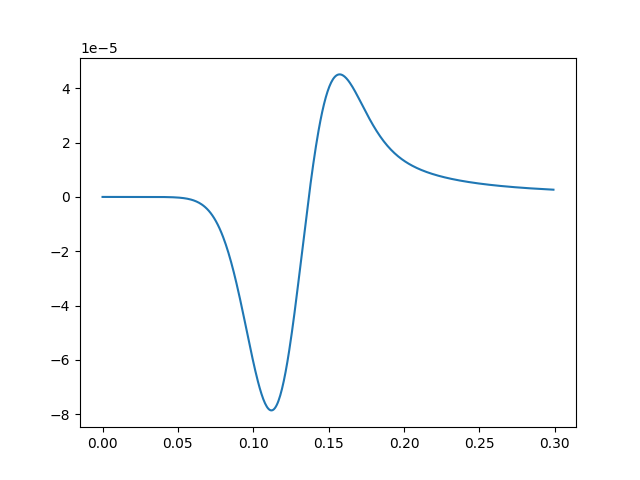

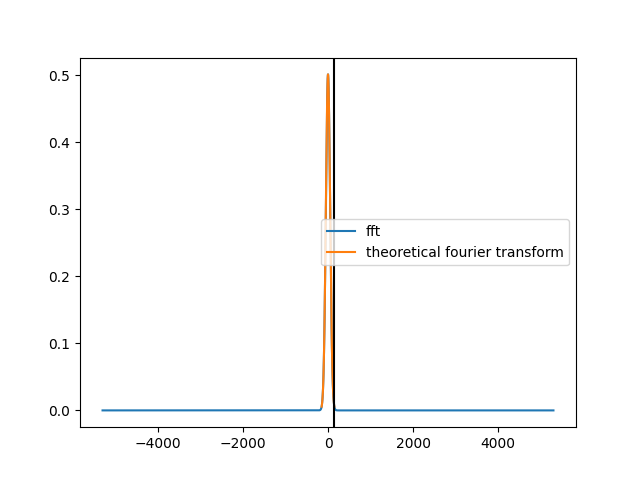

7283452.727182731


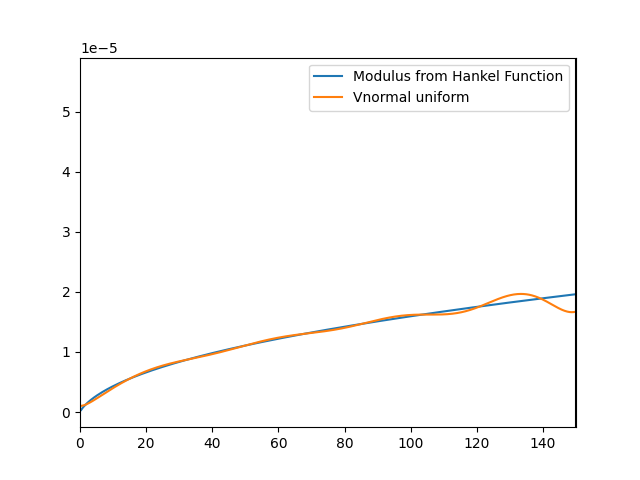

3.8101976435031917e-07


C:\Users\Sam_H\AppData\Local\Temp\ipykernel_14508\2857521853.py:58: RuntimeWarning: invalid value encountered in multiply
  Z= (1 / 4) * omega * mu0 * hankel2(0, d * omega * (mu0 * eps0) ** 0.5)


In [10]:
#validation

#fourier transformming signal
v=Ez_obs
t=np.arange(Nt) * dt
fig,ax=plt.subplots()
ax.plot(t,v)
plt.show()
V=np.fft.fft(v,n=100*len(v))
f=np.fft.fftfreq(len(v)*100,d=dt)
V=np.fft.fftshift(V)*dt
f=np.fft.fftshift(f)

#fourier transform current/checking fourier transform
J_f=np.fft.fft(Je_t,n=100*len(Je_t))
f=np.fft.fftfreq(len(Je_t)*100,d=dt)
J_f=np.fft.fftshift(J_f)*dt
f=np.fft.fftshift(f)


omega=2*np.pi*f
fig,ax=plt.subplots()
ax.plot(omega,np.abs(J_f),label="fft")
Jtheo=J0*np.sqrt(2*np.pi)*sigma*np.exp(-(omega**2)*(sigma**2)/2)
ax.plot(omega[(omega>-3/sigma) & (omega<3/sigma)],Jtheo[(omega>-3/sigma) & (omega<3/sigma)],label="theoretical fourier transform")
ax.axvline(x=3/sigma,color="black")
ax.legend()
plt.show()

#calculating distance
#only run this part for non uniform--------------------------
ps_x_co=np.sum(delta_x[:ps_x,0])
ps_y_co=np.sum(delta_y[0,:ps_y])
po_x_co=np.sum(delta_x[:po_x,0])
po_y_co=np.sum(delta_y[0,:po_y])
#--------------------------------------------------------------
d=np.sqrt((ps_x_co-po_x_co)**2+(ps_y_co-po_y_co)**2)
print(d)

#analytical solution
w = np.linspace(-omega_max, omega_max, 1000)
Z = (1 / 4) * w * mu0 * hankel2(0, d * w * (mu0 * eps0) ** 0.5)




fig,ax=plt.subplots()
ax.plot(w[(w>-3/sigma) & (w<3/sigma)], np.abs(Z[(w>-3/sigma) & (w<3/sigma)]), label="Modulus from Hankel Function")
ax.plot(omega[(omega>-3/sigma) & (omega<3/sigma)],np.abs(V[(omega>-3/sigma) & (omega<3/sigma)]/Jtheo[(omega>-3/sigma) & (omega<3/sigma)]),label="Vnormal uniform")
ax.axvline(x=3/sigma,color="black")
#ax.set_ylim([0,10**(-5)])
ax.set_xlim([0,3/(sigma)])
ax.legend()
plt.show()



Z= (1 / 4) * omega * mu0 * hankel2(0, d * omega * (mu0 * eps0) ** 0.5)
avr_error=np.sum(np.abs(np.abs(Z[(omega>0) & (omega<3/sigma)])- np.abs(V[(omega>0) & (omega<3/sigma)]/Jtheo[(omega>0) & (omega<3/sigma)])))/len(Z[(omega>0) & (omega<3/sigma)])
print(avr_error)






# # ── FFT van geobserveerd veld en bron ─────────────────────────
# Nfft   = 2*Nt    # zero-padding voor betere frequentieresolutie
# freqs  = np.fft.rfftfreq(Nfft, d=dt)   # [Hz]
# omegas = 2*np.pi*freqs

# Ez_fft = np.fft.rfft(Ez_obs, n=Nfft)
# Je_fft = np.fft.rfft(Je_t,   n=Nfft)

# # Bronspectrum (analytisch voor Gaussische puls)
# Je_spectrum_analytic = (J0 * sigma * np.sqrt(2*np.pi)
#                         * np.exp(-sigma**2 * omegas**2 / 2)
#                         * np.exp(-1j * omegas * tc))

# # Frequentierespons = E_z(omega) / J_e(omega)
# # Beperk tot bandbreedte van bron (omega < 3/sigma_t)
# omega_max  = 5 / sigma
# f_max      = omega_max / (2*np.pi)
# band_mask  = (freqs > 0) & (freqs <= f_max)

# # Transferfunctie (FDTD)
# H_fdtd = np.zeros_like(Ez_fft, dtype=complex)
# H_fdtd[band_mask] = Ez_fft[band_mask] / Je_spectrum_analytic[band_mask]

# # ── Analytische Hankel-functie ─────────────────────────────────
# xs_m = ps_x * dx
# ys_m = ps_y * dy
# xo_m = po_x * dx
# yo_m = po_y * dy
# r    = np.sqrt((xo_m - xs_m)**2 + (yo_m - ys_m)**2)

# f_plot = freqs[band_mask]
# om_plot = 2*np.pi*f_plot
# k0_plot = om_plot / c

# Ez_hankel = -J0 * om_plot * mu0 / 4 * hankel2(0, k0_plot * r)

# # ── Plot vergelijking ──────────────────────────────────────────
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# axes[0].plot(f_plot/1e9, np.abs(H_fdtd[band_mask]),
#              label='Yee-FDTD', lw=2)
# axes[0].plot(f_plot/1e9, np.abs(Ez_hankel),
#              '--', label='Hankel (analytisch)', lw=2)
# axes[0].set_xlabel('f [GHz]')
# axes[0].set_ylabel('$|E_z(f)|$ [V·m⁻¹·(A·m⁻²)⁻¹·Hz]')
# axes[0].set_title('Amplitude-spectrum — validatie')
# axes[0].legend()
# axes[0].grid(True, alpha=0.3)

# axes[1].plot(f_plot/1e9, np.angle(H_fdtd[band_mask]),
#              label='Yee-FDTD', lw=2)
# axes[1].plot(f_plot/1e9/2/np.pi, np.angle(Ez_hankel),
#              '--', label='Hankel (analytisch)', lw=2)
# axes[1].set_xlabel('f [GHz]')
# axes[1].set_ylabel('Fase [rad]')
# axes[1].set_title('Fase-spectrum — validatie')
# axes[1].legend()
# axes[1].grid(True, alpha=0.3)

# plt.suptitle(f'Observatiepunt op r = {r*1e3:.1f} mm van de bron'
#              + (' (ZONDER object)' if not USE_OBJECT else ' (MET object — validatie enkel geldig in vrije ruimte)'))
# plt.tight_layout()
# plt.show()

# # Relatieve fout
# rel_err = (np.abs(H_fdtd[band_mask] - Ez_hankel)
#            / (np.abs(Ez_hankel) + 1e-30))
# print(f'Gemiddelde relatieve fout (amplitude): {rel_err.mean()*100:.2f}%')
